Lab Lezione 5: Graph Neural Networks

**goal:** The aim is to classify the MNIST digit graphs into their respective classes.

**steps:**


1.   Load the complete dataset and check that it contains 60000 graphs data.
2.   Print a couple of digit graphs of the dataset.
3.   Implement the model (GNN part is already in the main file, you should implement the MLP classifier only)
4.   Train the model (already implemented)
5.   Evaluate the model performances during the test on the sub-dataset using the accuracy
6.   Try to optimize the model to increase the performance  



**hints:**


1. The task involves predicting >3 classes, which is a form of multiclass classification. To accomplish this, it is recommended to use the "crossentropy loss" function. When using the `nn.CrossEntropyLoss()` function, note that **it already includes a softmax function by default**. As a result, it is not necessary to use softmax as the activation function for the last layer. Instead, a linear activation function should be used.

2. When testing the model, it is important to pay attention to the output of the neural network. The network will return >3 outputs that correspond to the probability that the input belongs to a certain class (if you apply a softmax function). In this case, the focus should be on the index that corresponds to the class with the highest probability.

3. The GNN implemented in the main file is maybe too simple If you want to increase the model performance you could try to implement a more complex and deep GNN model. You can find the documentation at https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html .




Base code (modified later)

In [ ]:
import torch, torch_geometric
import matplotlib.pyplot as plt
from torch_geometric.datasets import MNISTSuperpixels
from torch_geometric.profile import get_model_size
from torch.nn import Softmax, Linear
from torch_geometric.nn import global_max_pool, SAGEConv
from torch_geometric.loader import DataLoader




def plotting(title, x, y):
    plt.figure(figsize=(10, 5))
    plt.title(title, fontsize=20)
    plt.plot(x, y, color='#88CCEE', linewidth=3)
    plt.xlabel('Epochs', fontsize=18)
    plt.ylabel(title, fontsize=18)
    plt.grid(True)
    plt.legend(fontsize=18)
    # plt.savefig('Graph_mnist'+ title +'.png')
    plt.show()




def accuracy(prediction, y):
    """Calculate accuracy."""
    return ((prediction.argmax(dim=1) == y).sum() / len(y)).item()




class GraphCNN(torch.nn.Module):
    def __init__(self, input_neurons, hidden_channels, conv_hidden_channels, output_neurons, learning_rate):
        super(GraphCNN, self).__init__()
        # Graph-convolution section:
        self.initial_conv = SAGEConv(in_channels=input_neurons, out_channels=conv_hidden_channels)
        self.convolutional_layer = SAGEConv(in_channels=conv_hidden_channels, out_channels=hidden_channels)
        # Global mean pooling layer:
        self.pooling = global_max_pool


        # TODO: DEFINE HERE THE LAYERS OF THE MLP CLASSIFIER
        # Hint: remember that the input size must match with the output size of the last graph_convolutional layer!
        self.lin1 = Linear(hidden_channels, hidden_channels)
        self.lin2 = Linear(hidden_channels, output_neurons)
       
        # Softmax nonlinear function:
        self.softmax = Softmax(dim=1)


        # TODO: DEFINE HERE THE OPTIMIZER
        self.optimizer = torch.optim.Adam(self.parameters(), lr=learning_rate)


        # TODO: DEFINE HERE THE CROSS ENTROPY LOSS
        self.loss = torch.nn.CrossEntropyLoss()


    def forward(self, input_data):
        x = input_data.x.float()
        edge_index = input_data.edge_index
        batch_index = input_data.batch
        # "batch_index" is a tensor that specify for each node its corresponding graph of the entire batch.
        # Example of batch index: [0,0,0,0,1,1,1,1,2,2,2,2....] The first 4 elements belong to the first graph,
        # the second 4 belong to the second graph and so on...


        x = self.initial_conv(x, edge_index)
        x = x.tanh()
        x = self.convolutional_layer(x, edge_index)
        x = x.tanh()
        x = self.convolutional_layer(x, edge_index)
        x = x.tanh()
        x = self.convolutional_layer(x, edge_index)
        x = x.tanh()


        x = self.pooling(x, batch_index)    # [n_nodes*n_graph_of_the_batch, n_features] -> [n_graph_of_the_batch, n_features]


        # TODO: here complete with your own MLP forward part
        self.lin1(x)
        x = x.tanh()
        output = self.lin2(x)


        return output


       


    def train(self, input_data):
        # Reset gradients
        self.optimizer.zero_grad()
        # Passing the node features and the connection info
        prediction = self.forward(input_data)
        # Calculating the loss and gradients
        loss = self.criterion(prediction, input_data.y)
        loss.backward()
        # Update using the gradients
        self.optimizer.step()
        # Computing accuracy based on prediction
        acc = accuracy(prediction, input_data.y)


        return loss.item(), acc




def main():


    # Dataset loading:
    dataset = MNISTSuperpixels(root="mnist", train=True)


    # For reasons of time, the dataset has been lightened. You can choose to use the entire data set, but it's up to you.
    num_classes = 3
    classes_set = [i for i in range(num_classes)]
    new_dataset = []
    for el in dataset:
        if el.y in classes_set:
            new_dataset.append(el)
    dataset_size = len(new_dataset)


    # Hyperparameters:
    batch_size = 35
    conv_hidden_channels = 4
    hidden_channels = 4
    num_epochs = 70
    learning_rate = 0.01


    # Creating dataloaders for storing and shuffling training data:
    train_loader = DataLoader(dataset=new_dataset[:int(dataset_size * 0.8)], batch_size=batch_size, shuffle=True)


    # Print some useful information:
    print('\nTraining of a GNN on the graph Mnist dataset')
    print(44 * '-')
    print('Dataset:')
    print("Number of graphs:\t\t\t\t\t  ", dataset_size)
    print("Number of node features:\t\t\t\t  ", dataset.num_node_features)
    print("Number of edge features:\t\t\t\t  ", dataset.num_edge_features)


    # TODO: Define your model here:
    model = GraphCNN(input_neurons=dataset.num_node_features,
        hidden_channels=hidden_channels,
        conv_hidden_channels=conv_hidden_channels,
        output_neurons=num_classes,
        learning_rate=learning_rate)


    # Model size and number of parameters of the model:
    print(44 * '-')
    print("Model:")
    print('Model size (bytes):\t\t\t\t\t  ', get_model_size(model))
    print("Number of parameters:\t\t\t\t   ", sum(p.numel() for p in model.parameters()))
    print(44 * '-')


    # Now it's time to train the GNN:
    epochs = range(1, num_epochs+1)
    train_losses, train_accuracies = [], []
    print('Training ...')
    for epoch in epochs:
        loss_per_epoch = []
        accuracy_per_epoch = []
        for i, mini_batch in enumerate(train_loader):
            train_loss, train_acc = model.train(mini_batch)
            loss_per_epoch.append(train_loss)
            accuracy_per_epoch.append(train_acc)


        train_losses.append(sum(loss_per_epoch)/len(loss_per_epoch))
        train_accuracies.append(100*sum(accuracy_per_epoch)/len(accuracy_per_epoch))


        print(f"Ep {epoch} \t| Loss {round(train_losses[-1], 5)} \t| Accuracy: {round(train_accuracies[-1], 3)} %")


    # TODO: Plot the train loss and the train accuracy over epochs (a plotting function is already present at the beginning of this code)
    plotting('Train loss', epochs, loss_per_epoch)
    plotting('Train accuracy', epochs, loss_per_epoch)
    # Here a test dataloader is created with batch_size = 1.
    test_loader = DataLoader(dataset=new_dataset[int(dataset_size * 0.8):], batch_size=1, shuffle=False)

    model.eval() # Imposta il modello in modalità di inferenza
    test_accuracies = []
    # TODO: Evaluate the model on test set by computing the value of the test accuracy.
    with torch.no_grad(): # Disabilita il calcolo del gradiente risparmiando memoria
        for mini_batch in test_loader:
            prediction = model(mini_batch) # Usiamo .forward implicito
            test_acc = accuracy(prediction, mini_batch.y)
            test_accuracies.append(test_acc)
            
    final_test_accuracy = 100 * sum(test_accuracies) / len(test_accuracies)
    print(f"Test Accuracy Finale: {round(final_test_accuracy, 3)} %\n")
    print(44 * '-')



if __name__ == main():
    main()


Official code (help by Gemini)


Training of a GNN on the graph Mnist dataset
--------------------------------------------
Dataset:
Number of graphs:					   18623
Number of node features:				   1
Number of edge features:				   0
--------------------------------------------
Model:
Model size (bytes):					   8229
Number of parameters:				    899
--------------------------------------------
Training ...
Ep 1 	| Loss 0.55603 	| Accuracy: 74.57 %
Ep 2 	| Loss 0.24835 	| Accuracy: 90.369 %
Ep 3 	| Loss 0.20446 	| Accuracy: 92.408 %
Ep 4 	| Loss 0.1965 	| Accuracy: 92.74 %
Ep 5 	| Loss 0.17575 	| Accuracy: 93.485 %
Ep 6 	| Loss 0.15571 	| Accuracy: 94.4 %
Ep 7 	| Loss 0.16079 	| Accuracy: 94.077 %
Ep 8 	| Loss 0.14252 	| Accuracy: 94.849 %
Ep 9 	| Loss 0.13173 	| Accuracy: 95.331 %
Ep 10 	| Loss 0.13691 	| Accuracy: 94.958 %
Ep 11 	| Loss 0.12247 	| Accuracy: 95.49 %
Ep 12 	| Loss 0.13948 	| Accuracy: 95.125 %
Ep 13 	| Loss 0.12589 	| Accuracy: 95.537 %
Ep 14 	| Loss 0.11967 	| Accuracy: 95.944 %
Ep 15 	| Loss 0.11586 	| Ac

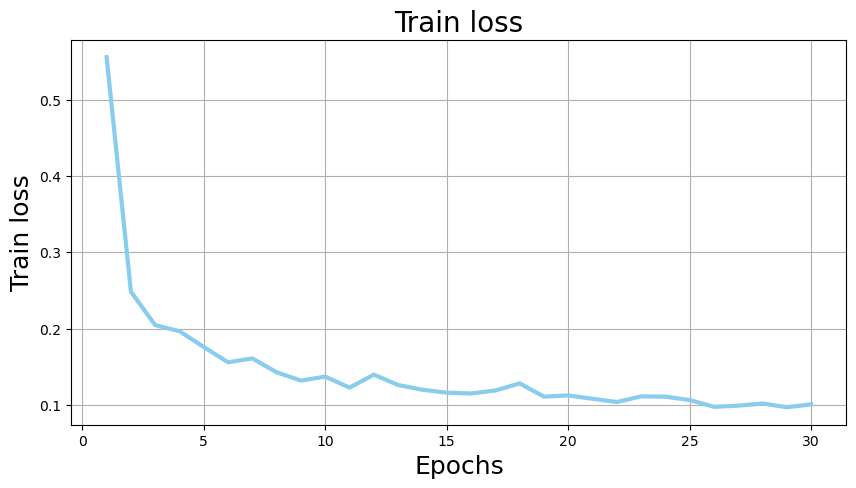

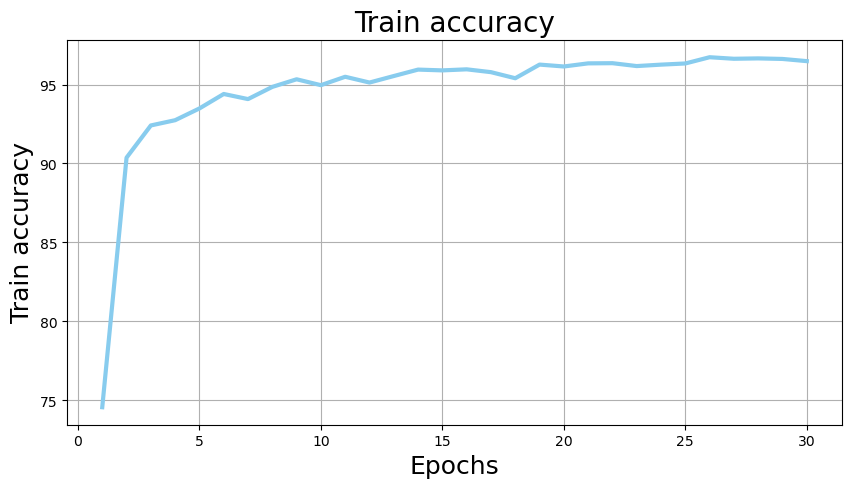

--------------------------------------------

Testing ...
Test Accuracy Finale: 95.275 %

--------------------------------------------


In [2]:
import torch, torch_geometric
import matplotlib.pyplot as plt
from torch_geometric.datasets import MNISTSuperpixels
from torch_geometric.profile import get_model_size
from torch.nn import Softmax, Linear
from torch_geometric.nn import global_max_pool, SAGEConv
from torch_geometric.loader import DataLoader

def plotting(title, x, y):
    plt.figure(figsize=(10, 5))
    plt.title(title, fontsize=20)
    plt.plot(x, y, color='#88CCEE', linewidth=3)
    plt.xlabel('Epochs', fontsize=18)
    plt.ylabel(title, fontsize=18)
    plt.grid(True)
    # plt.legend(fontsize=18) 
    # plt.savefig('Graph_mnist'+ title +'.png')
    plt.show()

def accuracy(prediction, y):
    """Calculate accuracy."""
    return ((prediction.argmax(dim=1) == y).sum() / len(y)).item()

class GraphCNN(torch.nn.Module):
    def __init__(self, input_neurons, hidden_channels, conv_hidden_channels, output_neurons, learning_rate):
        super(GraphCNN, self).__init__()
        
        # Primo strato: trasforma le feature iniziali (input_neurons) in conv_hidden_channels (2)
        self.initial_conv = SAGEConv(in_channels=input_neurons, out_channels=conv_hidden_channels)
        self.convolutional_layer = SAGEConv(in_channels=conv_hidden_channels, out_channels=hidden_channels)
        # Global pooling: riduce il grafo a un singolo vettore
        self.pooling = global_max_pool

        # MLP CLASSIFIER: 
        # L'input deve corrispondere alla dimensione in uscita dalle convoluzioni (conv_hidden_channels)
        self.lin1 = Linear(hidden_channels, hidden_channels)
        self.lin2 = Linear(hidden_channels, output_neurons)
        # Nonlinear function
        self.softmax = Softmax(dim=1)
        # Optimizer
        self.optimizer = torch.optim.Adam(self.parameters(), lr=learning_rate)
        # Cross entropy loss
        self.criterion = torch.nn.CrossEntropyLoss()

    def forward(self, input_data):
        x = input_data.x.float()
        edge_index = input_data.edge_index
        batch_index = input_data.batch #tensor that specify for each node its corresponding graph of the entire batch

        # Passaggio 1: Input -> 2 canali
        x = self.initial_conv(x, edge_index)
        x = x.tanh()
        # Passaggio 2, 3, 4: 2 canali -> 2 canali (Sempre coerente)
        x = self.convolutional_layer(x, edge_index)
        x = x.tanh()
        x = self.convolutional_layer(x, edge_index)
        x = x.tanh()
        x = self.convolutional_layer(x, edge_index)
        x = x.tanh()

        # Pooling: x resta di dimensione 2
        x = self.pooling(x, batch_index)   # [n_nodes*n_graph_of_the_batch, n_features] -> [n_graph_of_the_batch, n_features] 

        # MLP: da 2 passa a hidden_channels(4) e poi a output(3)
        x = self.lin1(x)
        x = x.tanh()
        output = self.lin2(x)

        return output
    
    def train_step(self, input_data):
        #reset gradients
        self.optimizer.zero_grad() 
        # Passing the node features and the connection info
        prediction = self.forward(input_data)
        # Calculating the loss and gradients
        loss = self.criterion(prediction, input_data.y)
        loss.backward()
        # Update using the gradients
        self.optimizer.step()
        # Computing accuracy based on prediction
        acc = accuracy(prediction, input_data.y)

        return loss.item(), acc
    

def main():

    # Dataset loading:
    dataset = MNISTSuperpixels(root="mnist", train=True)

    num_classes = 3
    classes_set = [i for i in range(num_classes)]
    new_dataset = []
    for el in dataset:
        if el.y in classes_set:
            new_dataset.append(el)
    dataset_size = len(new_dataset)

    # Hyperparameters:
    batch_size = 64
    conv_hidden_channels = 16
    hidden_channels = 16
    num_epochs = 30
    learning_rate = 0.01

    # Creating dataloaders
    train_loader = DataLoader(dataset=new_dataset[:int(dataset_size * 0.8)], batch_size=batch_size, shuffle=True)

    print('\nTraining of a GNN on the graph Mnist dataset')
    print(44 * '-')
    print('Dataset:')
    print("Number of graphs:\t\t\t\t\t  ", dataset_size)
    print("Number of node features:\t\t\t\t  ", dataset.num_node_features)
    print("Number of edge features:\t\t\t\t  ", dataset.num_edge_features)

    # Inizializzazione modello 
    model = GraphCNN(
        input_neurons=dataset.num_node_features,
        hidden_channels=hidden_channels,
        conv_hidden_channels=conv_hidden_channels,
        output_neurons=num_classes,
        learning_rate=learning_rate)

    print(44 * '-')
    print("Model:")
    print('Model size (bytes):\t\t\t\t\t  ', get_model_size(model))
    print("Number of parameters:\t\t\t\t   ", sum(p.numel() for p in model.parameters()))
    print(44 * '-')

    epochs = range(1, num_epochs+1)
    train_losses, train_accuracies = [], []
    
    print('Training ...')
    model.train() # Imposta PyTorch in modalità di training
    for epoch in epochs:
        loss_per_epoch = []
        accuracy_per_epoch = []
        for i, mini_batch in enumerate(train_loader):
            train_loss, train_acc = model.train_step(mini_batch)
            loss_per_epoch.append(train_loss)
            accuracy_per_epoch.append(train_acc)

        train_losses.append(sum(loss_per_epoch)/len(loss_per_epoch))
        train_accuracies.append(100*sum(accuracy_per_epoch)/len(accuracy_per_epoch))

        print(f"Ep {epoch} \t| Loss {round(train_losses[-1], 5)} \t| Accuracy: {round(train_accuracies[-1], 3)} %")

    # Passate le variabili corrette per il plotting
    plotting('Train loss', epochs, train_losses)
    plotting('Train accuracy', epochs, train_accuracies)

    # ====================================================
    # FASE DI TEST
    # ====================================================
    print(44 * '-')
    print('\nTesting ...')
    
    test_loader = DataLoader(dataset=new_dataset[int(dataset_size * 0.8):], batch_size=1, shuffle=False)
    model.eval() # Imposta il modello in modalità di inferenza
    test_accuracies = []
    
    with torch.no_grad(): # Disabilita il calcolo del gradiente risparmiando memoria
        for mini_batch in test_loader:
            prediction = model(mini_batch) # Usiamo .forward implicito
            test_acc = accuracy(prediction, mini_batch.y)
            test_accuracies.append(test_acc)
            
    final_test_accuracy = 100 * sum(test_accuracies) / len(test_accuracies)
    print(f"Test Accuracy Finale: {round(final_test_accuracy, 3)} %\n")
    print(44 * '-')


if __name__ == '__main__':
    main()

Gemini + ottimizzazione iperparametri + heatmap


Starting Hyperparameter Grid Search on MNIST Superpixels
--------------------------------------------
Total combinations to test: 9

Testing Configuration: conv_channels=4, hidden_channels=4
--> Test Accuracy: 34.87%

Testing Configuration: conv_channels=4, hidden_channels=8
--> Test Accuracy: 83.51%

Testing Configuration: conv_channels=4, hidden_channels=16
--> Test Accuracy: 81.95%

Testing Configuration: conv_channels=8, hidden_channels=4
--> Test Accuracy: 34.87%

Testing Configuration: conv_channels=8, hidden_channels=8
--> Test Accuracy: 90.1%

Testing Configuration: conv_channels=8, hidden_channels=16
--> Test Accuracy: 94.47%

Testing Configuration: conv_channels=16, hidden_channels=4
--> Test Accuracy: 34.87%

Testing Configuration: conv_channels=16, hidden_channels=8
--> Test Accuracy: 92.41%

Testing Configuration: conv_channels=16, hidden_channels=16
--> Test Accuracy: 92.54%

Grid Search Completed. Generating Heatmap...


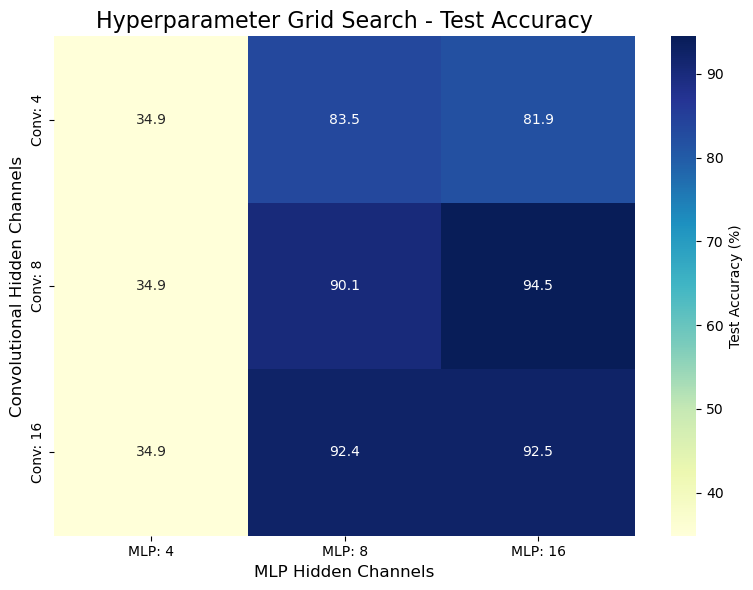

In [1]:
import torch, torch_geometric
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from torch_geometric.datasets import MNISTSuperpixels
from torch_geometric.profile import get_model_size
from torch.nn import Softmax, Linear
from torch_geometric.nn import global_max_pool, SAGEConv
from torch_geometric.loader import DataLoader

def plotting(title, x, y):
    plt.figure(figsize=(10, 5))
    plt.title(title, fontsize=20)
    plt.plot(x, y, color='#88CCEE', linewidth=3)
    plt.xlabel('Epochs', fontsize=18)
    plt.ylabel(title, fontsize=18)
    plt.grid(True)
    plt.show()

def accuracy(prediction, y):
    """Calculate accuracy."""
    return ((prediction.argmax(dim=1) == y).sum() / len(y)).item()

class GraphCNN(torch.nn.Module):
    def __init__(self, input_neurons, hidden_channels, conv_hidden_channels, output_neurons, learning_rate):
        super(GraphCNN, self).__init__()
        
        # SAGEConv layers
        self.initial_conv = SAGEConv(in_channels=input_neurons, out_channels=conv_hidden_channels)
        self.convolutional_layer = SAGEConv(in_channels=conv_hidden_channels, out_channels=conv_hidden_channels)
        
        # Global pooling
        self.pooling = global_max_pool

        # MLP CLASSIFIER
        self.lin1 = Linear(conv_hidden_channels, hidden_channels)
        self.lin2 = Linear(hidden_channels, output_neurons)
        
        self.optimizer = torch.optim.Adam(self.parameters(), lr=learning_rate)
        self.criterion = torch.nn.CrossEntropyLoss()

    def forward(self, input_data):
        x = input_data.x.float()
        edge_index = input_data.edge_index
        batch_index = input_data.batch

        # Convolutions
        x = self.initial_conv(x, edge_index).relu()
        x = self.convolutional_layer(x, edge_index).relu()
        x = self.convolutional_layer(x, edge_index).relu()
        x = self.convolutional_layer(x, edge_index).relu()

        # Pooling
        x = self.pooling(x, batch_index)    

        # MLP
        x = self.lin1(x).relu()
        output = self.lin2(x)

        return output
    
    def train_step(self, input_data):
        self.optimizer.zero_grad()
        prediction = self.forward(input_data)
        loss = self.criterion(prediction, input_data.y)
        loss.backward()
        self.optimizer.step()
        acc = accuracy(prediction, input_data.y)
        return loss.item(), acc
    

def main():
    # ==========================================
    # 1. Dataset loading
    # ==========================================
    dataset = MNISTSuperpixels(root="mnist", train=True)

    num_classes = 3
    classes_set = [i for i in range(num_classes)]
    new_dataset = [el for el in dataset if el.y in classes_set]
    dataset_size = len(new_dataset)

    # Dataloaders
    batch_size = 64
    train_loader = DataLoader(dataset=new_dataset[:int(dataset_size * 0.8)], batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(dataset=new_dataset[int(dataset_size * 0.8):], batch_size=64, shuffle=False) # Aumentato a 64 per velocizzare il test

    # ==========================================
    # 2. Hyperparameter Grid Setup
    # ==========================================
    num_epochs = 20 # Abbassato per rendere il tempo di calcolo della Grid Search accettabile
    learning_rate = 0.01
    
    # Iperparametri da iterare
    conv_channels_list = [4, 8, 16]
    hidden_channels_list = [4, 8, 16]
    
    # Matrice per salvare i risultati (Heatmap)
    results_matrix = np.zeros((len(conv_channels_list), len(hidden_channels_list)))

    print('\nStarting Hyperparameter Grid Search on MNIST Superpixels')
    print(44 * '-')
    print(f"Total combinations to test: {len(conv_channels_list) * len(hidden_channels_list)}")

    # ==========================================
    # 3. Grid Search Loop
    # ==========================================
    for i, conv_ch in enumerate(conv_channels_list):
        for j, hid_ch in enumerate(hidden_channels_list):
            
            print(f"\nTesting Configuration: conv_channels={conv_ch}, hidden_channels={hid_ch}")
            
            # Inizializziamo un nuovo modello per ogni configurazione
            model = GraphCNN(
                input_neurons=dataset.num_node_features,
                hidden_channels=hid_ch,
                conv_hidden_channels=conv_ch,
                output_neurons=num_classes,
                learning_rate=learning_rate
            )

            # --- TRAINING ---
            model.train()
            for epoch in range(1, num_epochs+1):
                epoch_accuracies = []
                for mini_batch in train_loader:
                    _, train_acc = model.train_step(mini_batch)
                    epoch_accuracies.append(train_acc)

            # --- TESTING ---
            model.eval()
            test_accuracies = []
            with torch.no_grad():
                for mini_batch in test_loader:
                    prediction = model(mini_batch)
                    test_acc = accuracy(prediction, mini_batch.y)
                    test_accuracies.append(test_acc)
                    
            final_test_accuracy = 100 * sum(test_accuracies) / len(test_accuracies)
            print(f"--> Test Accuracy: {round(final_test_accuracy, 2)}%")
            
            # Salviamo il risultato nella matrice
            results_matrix[i, j] = final_test_accuracy

    # ==========================================
    # 4. Generate Heatmap
    # ==========================================
    print("\nGrid Search Completed. Generating Heatmap...")
    
    # Convertiamo in DataFrame di Pandas per una visualizzazione migliore con Seaborn
    df_results = pd.DataFrame(
        results_matrix, 
        index=[f"Conv: {ch}" for ch in conv_channels_list],
        columns=[f"MLP: {ch}" for ch in hidden_channels_list]
    )

    plt.figure(figsize=(8, 6))
    sns.heatmap(df_results, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Test Accuracy (%)'})
    plt.title("Hyperparameter Grid Search - Test Accuracy", fontsize=16)
    plt.xlabel("MLP Hidden Channels", fontsize=12)
    plt.ylabel("Convolutional Hidden Channels", fontsize=12)
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()